In [1]:
!python --version
import os
import warnings
print (os.environ['CONDA_DEFAULT_ENV'])

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.10.18
base


# 1. Workbook setups

## 1.1 Import packages

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import statsmodels.api as sm

import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time


## 1.2 Miscellaneous codes

In [4]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,lon2 = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(lon2,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    lon1, lat1 = origin
    lon2, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient



### 1.2.1 Pred TEX and Pred SST from previous calibrations

In [5]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten2002, schouten2003, kim2008, OBrien2017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten2002':(66.6667,-18.6667),
        'schouten2003':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien2017':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_coretop_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_coretop_linear':(69.61698822,-16.73443208),
        'low23_coretop_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_coretop_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_coretop_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_coretop_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten2002, schouten2003, kim2008, OBrien2017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten2002':(0.015,0.280),
        'schouten2003':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien2017':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_coretop_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_coretop_linear':(69.61698822,-16.73443208),
        'low23_coretop_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_coretop_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_coretop_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_coretop_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## 1.3 Dictionaries

In [6]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


## 1.4 Set local paths

In [ ]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path

preferred = Path("/opt/cmdstan/cmdstan-2.36.0")
if (preferred / "bin" / "stanc").exists():
    set_cmdstan_path(str(preferred))
    print("Set CMDSTAN ->", cmdstan_path())
else:
    print("Preferred CmdStan not found:", preferred)
    print("Using:", cmdstan_path())


from TEXAS.utils.paths import PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE, DOCUMENTS
print(PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE, DOCUMENTS)

from cmdstanpy import cmdstan_path
from pathlib import Path


print("CmdStan in use:", cmdstan_path())
print("OneDrive mount exists? ", Path("/mnt/onedrive").exists())


local_github_path = str(PROJECT_ROOT)  # shim for old code
local_onedrive_path = str(ONEDRIVE)
local_documents_path = str(DOCUMENTS)

Set CMDSTAN -> /opt/cmdstan/cmdstan-2.36.0
/home/micromamba/app /home/micromamba/app/TEXAS /home/micromamba/app/TEXAS/stan_models /opt/cmdstan/cmdstan-2.36.0 /mnt/onedrive /home/micromamba/Documents
CmdStan in use: /opt/cmdstan/cmdstan-2.36.0
OneDrive mount exists?  True


# 2. Import data

## 2.1 Import Ocean Data Products

In [8]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_04.nc'),decode_times=False).drop('time')

T_da = ts.isel(time=0).load()
T_da

<xarray.Dataset>
Dimensions:             (lat: 720, nbounds: 2, lon: 1440, depth: 102)
Coordinates:
  * lat                 (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon                 (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * depth               (depth) float32 0.0 5.0 10.0 ... 5.3e+03 5.4e+03 5.5e+03
Dimensions without coordinates: nbounds
Data variables: (12/14)
    crs                 int32 -2147483647
    lat_bnds            (lat, nbounds) float32 -90.0 -89.75 ... 89.75 90.0
    lon_bnds            (lon, nbounds) float32 -180.0 -179.8 ... 179.8 180.0
    depth_bnds          (depth, nbounds) float32 0.0 2.5 ... 5.45e+03 5.5e+03
    climatology_bounds  (nbounds) float32 1.704e+03 2.064e+03
    t_an                (depth, lat, lon) float32 nan nan nan ... nan nan nan
    ...                  ...
    t_sd                (depth, lat, lon) float32 nan nan nan ... nan nan nan
    t_se                (depth, lat, lon) float32 nan nan nan ... nan nan nan
    t_oa                (depth, lat, lon) float32 nan nan nan ... nan nan nan
    t_gp                (depth, lat, lon) float64 nan nan nan ... nan nan nan
    t_sdo               (depth, lat, lon) float32 nan nan nan ... nan nan nan
    t_sea               (depth, lat, lon) float32 nan nan nan ... nan nan nan
Attributes: (12/45)
    Conventions:                     CF-1.6
    title:                           World Ocean Atlas 2023 : sea_water_tempe...
    summary:                         Climatological mean temperature for the ...
    references:                      Locarnini, R.A., A.V. Mishonov, O.K. Bar...
    institution:                     NOAA National Centers for Environmental ...
    comment:                         Global Climatology as part of the World ...
    ...                              ...
    ncei_template_version:           NCEI_NetCDF_Grid_Template_v1.0
    license:                         These data are openly available to the p...
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    metadata_link:                   https://www.ncei.noaa.gov/products/world...
    date_created:                    2024-01-28 
    date_modified:                   2024-01-28

In [9]:
import glob

fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature/monthly'
### read multiple netcdf files
nc_files = sorted(glob.glob(os.path.join(fpath2, '*.nc')))

ds = xr.open_mfdataset(nc_files, decode_times=False, combine='by_coords', engine="h5netcdf").drop('time')
## assign month as coordinates from 1 to 12 
ds['month'] = np.arange(1,13)
ds

<xarray.Dataset>
Dimensions:             (time: 12, lat: 720, nbounds: 2, lon: 1440, depth: 57,
                         month: 12)
Coordinates:
  * lat                 (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon                 (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * depth               (depth) float32 0.0 5.0 10.0 ... 1.45e+03 1.5e+03
  * month               (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: time, nbounds
Data variables: (12/15)
    crs                 (time) int32 -2147483647 -2147483647 ... -2147483647
    lat_bnds            (time, lat, nbounds) float32 dask.array<chunksize=(1, 720, 2), meta=np.ndarray>
    lon_bnds            (time, lon, nbounds) float32 dask.array<chunksize=(1, 1440, 2), meta=np.ndarray>
    depth_bnds          (time, depth, nbounds) float32 dask.array<chunksize=(1, 57, 2), meta=np.ndarray>
    climatology_bounds  (time, nbounds) float32 dask.array<chunksize=(1, 2), meta=np.ndarray>
    t_an                (time, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    ...                  ...
    t_se                (time, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    t_oa                (time, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    t_ma                (time, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    t_gp                (time, depth, lat, lon) float64 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    t_sdo               (time, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    t_sea               (time, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
Attributes: (12/45)
    Conventions:                     CF-1.6
    title:                           World Ocean Atlas 2023 : sea_water_tempe...
    summary:                         Climatological mean temperature for the ...
    references:                      Locarnini, R.A., A.V. Mishonov, O.K. Bar...
    institution:                     NOAA National Centers for Environmental ...
    comment:                         Global Climatology as part of the World ...
    ...                              ...
    ncei_template_version:           NCEI_NetCDF_Grid_Template_v1.0
    license:                         These data are openly available to the p...
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    metadata_link:                   https://www.ncei.noaa.gov/products/world...
    date_created:                    2024-01-28 
    date_modified:                   2024-01-28

In [10]:
import sys, xarray as xr
print(sys.executable)
try:
    import dask
    print("dask:", dask.__version__)
except Exception as e:
    print("dask not importable:", e)
print("xarray:", xr.__version__)


/opt/conda/bin/python
dask: 2025.7.0
xarray: 2023.7.0


In [11]:
T_diff = ds.t_an.isel(depth=0).max(dim='time') - ds.t_an.isel(depth=0).min(dim='time')
T_max = ds.t_an.isel(depth=0).max(dim='time')
T_min = ds.t_an.isel(depth=0).min(dim='time')

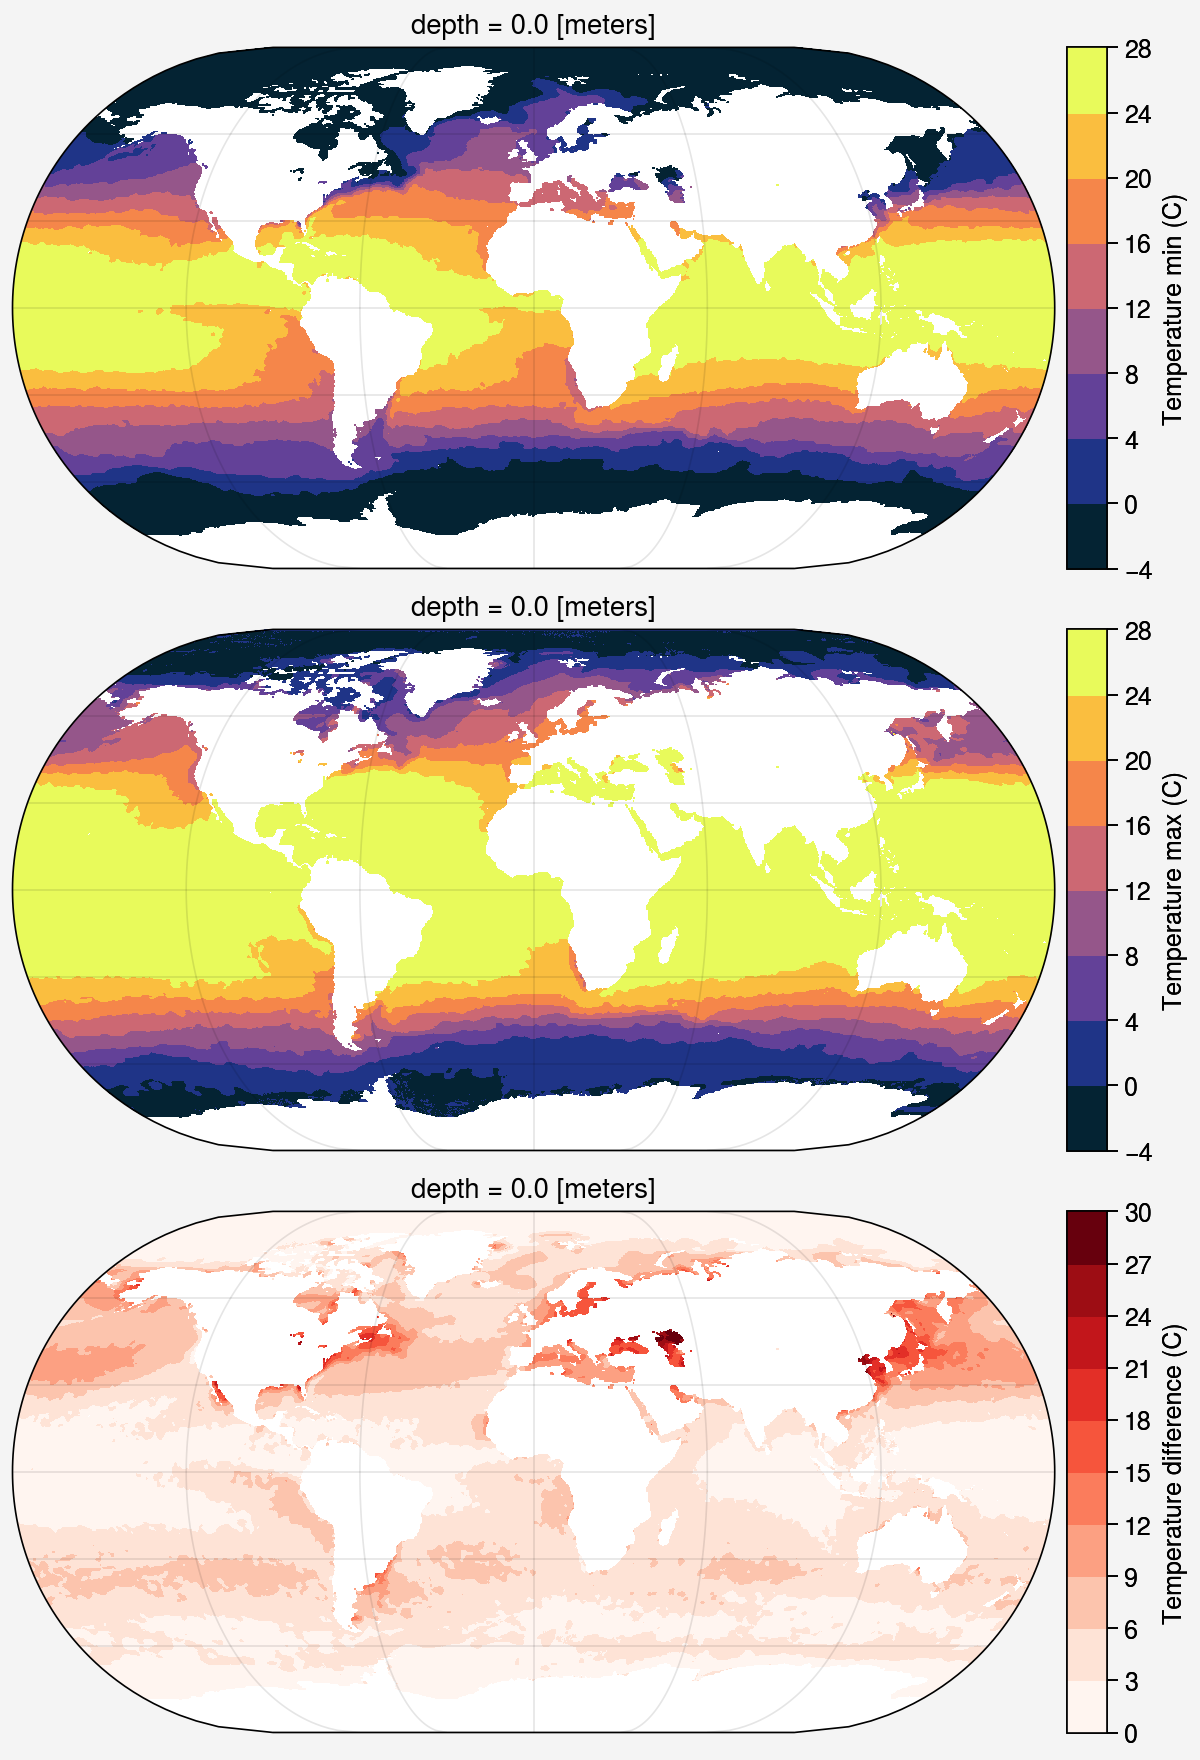

In [12]:
fig, axs = plot.subplots(nrows=3,proj='eck3',width=6)
T_min.plot(ax=axs[0],robust=True,vmin=-4,vmax=30, cmap='cmo.thermal', cbar_kwargs={'label':'Temperature min (C)'})
T_max.plot(ax=axs[1],robust=True,vmin=-4,vmax=30, cmap='cmo.thermal', cbar_kwargs={'label':'Temperature max (C)'})
T_diff.plot(ax=axs[2],robust=True,vmin=0,vmax=30, cmap='reds', cbar_kwargs={'label':'Temperature difference (C)'})

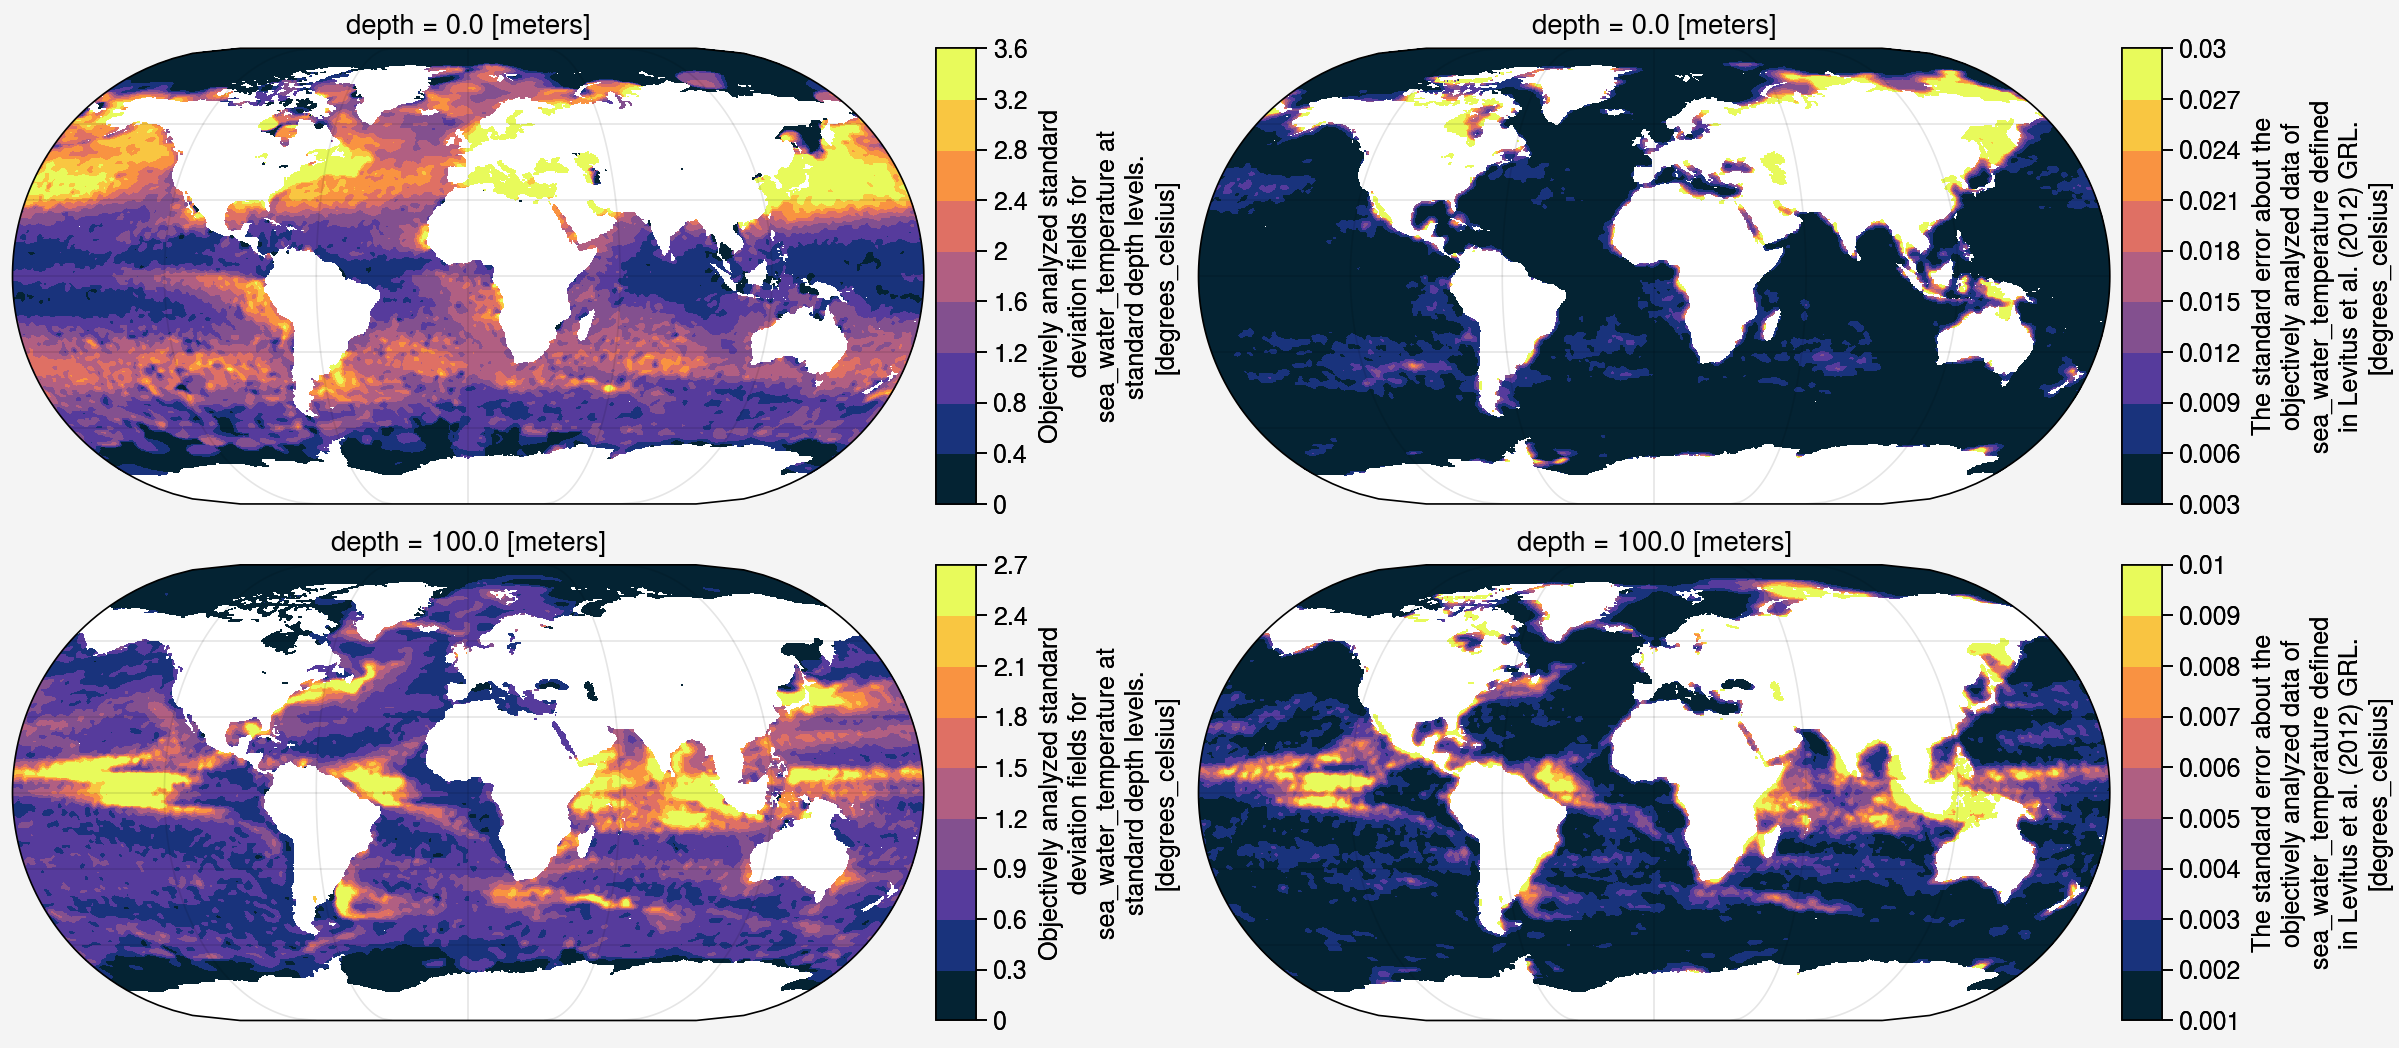

In [13]:
fig, axs = plot.subplots(width=12,proj='eck3',nrows=2,ncols=2)

ax = axs[0,0]
T_da.t_sdo.sel(depth=0,method='nearest').plot(cmap='cmo.thermal',robust=True,ax=ax,rasterized=True)

ax = axs[0,1]
T_da.t_sea.sel(depth=0,method='nearest').plot(cmap='cmo.thermal',robust=True,ax=ax,rasterized=True)

ax = axs[1,0]
T_da.t_sdo.sel(depth=100,method='nearest').plot(cmap='cmo.thermal',robust=True,ax=ax,rasterized=True)

ax = axs[1,1]
T_da.t_sea.sel(depth=100,method='nearest').plot(cmap='cmo.thermal',robust=True,ax=ax,rasterized=True)

In [14]:
fpath = f'{local_github_path}/nc_files/'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_properties_ds = xr.open_dataset(os.path.join(fpath, fname))
ocean_properties_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

## 2.2 Import culture and mesocosm data

In [15]:
### Regression dataset compilation
fpath = fr'{local_github_path}/spreadsheets'
fname = r'culture_mesocosm_combined_rev_030425.csv'

culture_meso_df = pd.read_csv(os.path.join(fpath, fname))
culture_meso_growthrate = culture_meso_df[culture_meso_df['experiment_setup'].isin(['culture-growth-rate','culture-oxygen'])].reset_index(drop=True)  
culture_meso_df = culture_meso_df[culture_meso_df['experiment_setup'].isin(['mesocosm','culture-temperature'])].reset_index(drop=True)
culture_meso_df['gdgt23ratio'] = culture_meso_df['fGDGT_2']/culture_meso_df['fGDGT_3']
# culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Sinninghe Damste et al. (2002) Journal of Lipid Research'].reset_index(drop=True)
culture_meso_df['Strains_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['Strains'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['Strains_edited'].iloc[i] = culture_meso_df['Strains'].iloc[i]

culture_meso_df['GTDB_genus_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['GTDB_genus'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['GTDB_genus_edited'].iloc[i] = culture_meso_df['GTDB_genus'].iloc[i]

culture_meso_df


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,Strains_edited,GTDB_genus_edited
0,TEXAS_PSM_mesocosm_RR001,meso_001,Wuchter2004,10,0.334578,1.967739,0.491935,2.685656,0.0,mesocosm,...,0.012109,0.438521,0.003929,mesocosm,0.241927,0.487032,0,NaN,mesocosm - North Sea,mesocosm - North Sea
1,TEXAS_PSM_mesocosm_RR002,meso_002,Wuchter2004,15,0.288381,1.939119,0.484780,2.190909,0.0,mesocosm,...,0.010262,0.440331,0.003284,mesocosm,0.215210,0.496802,0,NaN,mesocosm - North Sea,mesocosm - North Sea
2,TEXAS_PSM_mesocosm_RR003,meso_003,Wuchter2004,15,0.239814,1.856318,0.464080,2.250000,0.0,mesocosm,...,0.008398,0.420618,0.003394,mesocosm,0.227084,0.517657,0,NaN,mesocosm - North Sea,mesocosm - North Sea
3,TEXAS_PSM_mesocosm_RR004,meso_004,Wuchter2004,22,0.466403,2.991935,0.747984,2.858779,0.0,mesocosm,...,0.010061,0.706605,0.006490,mesocosm,0.112805,0.217354,0,NaN,mesocosm - North Sea,mesocosm - North Sea
4,TEXAS_PSM_mesocosm_RR005,meso_005,Wuchter2004,25,0.461538,3.058343,0.764586,1.763466,0.0,mesocosm,...,0.009937,0.730742,0.007447,mesocosm,0.084560,0.209466,0,NaN,mesocosm - North Sea,mesocosm - North Sea
5,TEXAS_PSM_mesocosm_RR006,meso_006,Wuchter2004,25,0.483547,3.228140,0.807035,3.037383,0.0,mesocosm,...,0.008200,0.770174,0.007434,mesocosm,0.089465,0.159348,0,NaN,mesocosm - North Sea,mesocosm - North Sea
6,TEXAS_PSM_mesocosm_RR007,meso_007,Wuchter2004,30,0.527554,3.043329,0.760832,4.415385,0.0,mesocosm,...,0.013087,0.694626,0.009503,mesocosm,0.168660,0.180523,0,NaN,mesocosm - North Sea,mesocosm - North Sea
7,TEXAS_PSM_mesocosm_RR008,meso_008,Wuchter2004,35,0.705459,3.162726,0.790682,5.052474,0.0,mesocosm,...,0.020833,0.696505,0.011556,mesocosm,0.205871,0.134653,0,NaN,mesocosm - North Sea,mesocosm - North Sea
8,TEXAS_PSM_mesocosm_RR009,meso_009,Wuchter2004,13,0.263181,1.874010,0.468502,2.705674,0.0,mesocosm,...,0.004826,0.441531,0.002533,mesocosm,0.144562,0.521336,0,NaN,mesocosm - North Sea,mesocosm - North Sea
9,TEXAS_PSM_mesocosm_RR010,meso_010,Wuchter2004,15,0.309940,2.180438,0.545109,2.971429,0.0,mesocosm,...,0.009007,0.497320,0.004973,mesocosm,0.201160,0.427407,0,NaN,mesocosm - North Sea,mesocosm - North Sea


## 2.3 Import coretop data

In [16]:
fpath = f'{local_github_path}/nc_files/'
fname = 'ds04_gridded_coretop_tex_scaledRI.nc'
coretop_ds = xr.open_dataset(os.path.join(fpath, fname))
coretop_ds

<xarray.Dataset>
Dimensions:                    (lat: 720, lon: 1440)
Coordinates:
  * lat                        (lat) float32 -89.88 -89.62 ... 89.62 89.88
  * lon                        (lon) float32 -179.9 -179.6 ... 179.6 179.9
Data variables: (12/15)
    region_ID                  (lon, lat) float64 ...
    tex_count                  (lon, lat) float64 ...
    tex_median                 (lon, lat) float64 ...
    tex_mean                   (lon, lat) float64 ...
    tex_std                    (lon, lat) float64 ...
    scaledRI_count             (lon, lat) float64 ...
    ...                         ...
    gdgt23ratio_count          (lon, lat) float64 ...
    gdgt23ratio_median         (lon, lat) float64 ...
    gdgt23ratio_mean           (lon, lat) float64 ...
    gdgt23ratio_std            (lon, lat) float64 ...
    modernWaterDepth_mean      (lon, lat) float64 ...
    mahalanobis_distance_mean  (lon, lat) float64 ...
Attributes:
    title:             Gridded coretop TEX86 data
    long_name:         statistics of TEX86 for each grid cell with the same l...
    units:             TEX86 [unitless], Scaled RI [unitless]
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    processing_level:  Derived product
    history:           Computed from the global compilation of core-top GDGT ...
    references:        This study

In [17]:
coretop_ds_merged = xr.merge([coretop_ds, ocean_properties_ds])
coretop_da = coretop_ds_merged.to_dataframe().dropna(subset=['scaledRI_median','t_sf2tc_avg']).reset_index()
coretop_da

,lat,lon,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,scaledRI_mean,...,gdgt23ratio_median,gdgt23ratio_mean,gdgt23ratio_std,modernWaterDepth_mean,mahalanobis_distance_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc
0,-77.875,-40.375,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,0.509982,...,1.502839,1.502839,NaN,928.0,2.684224,NaN,NaN,-1.636017,30.0,-1.75611
1,-77.375,-158.375,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,0.438075,...,2.833333,2.833333,NaN,1081.0,2.016756,NaN,NaN,-1.586854,50.0,-1.66971
2,-77.125,-45.375,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,0.410931,...,1.824832,1.824832,NaN,332.0,2.380477,NaN,NaN,-1.692642,30.0,-1.76631
3,-76.625,-35.375,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,0.433342,...,2.066396,2.066396,NaN,932.0,2.422640,28.365620,28.426125,-1.498910,10.0,-1.56971
4,-76.375,-33.875,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,0.447518,...,2.040640,2.040640,NaN,839.0,2.392552,29.118933,29.757280,-1.651191,40.0,-1.75551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458,84.875,40.625,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,0.459150,...,4.516129,4.516129,NaN,4018.0,2.447200,7.665815,9.033155,-1.373924,125.0,0.08159
1459,86.625,152.125,3.0,1.0,0.490000,0.490000,NaN,1.0,0.382600,0.382600,...,21.272727,21.272727,NaN,1467.0,3.324040,7.059811,9.083502,-1.156047,175.0,0.24909
1460,86.875,-146.125,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,0.399850,...,9.555556,9.555556,NaN,3368.0,4.652252,8.384475,9.424562,-1.477433,150.0,-0.88321
1461,87.125,104.625,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,0.433075,...,2.870370,2.870370,NaN,4443.0,3.303009,6.828367,8.589128,-1.377392,150.0,-0.05211


# 3. Define curve fit functions

In [18]:
def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

In [19]:
culture_meso_df.groupby('Strains_edited').size().sort_values(ascending=False).reset_index(name='counts')

,Strains_edited,counts
0,mesocosm - North Sea,15
1,mesocosm - Seychelles,6


(<matplotlib.collections.PathCollection at 0x7fd067d22d10>,
 <matplotlib.collections.PathCollection at 0x7fd078104af0>)

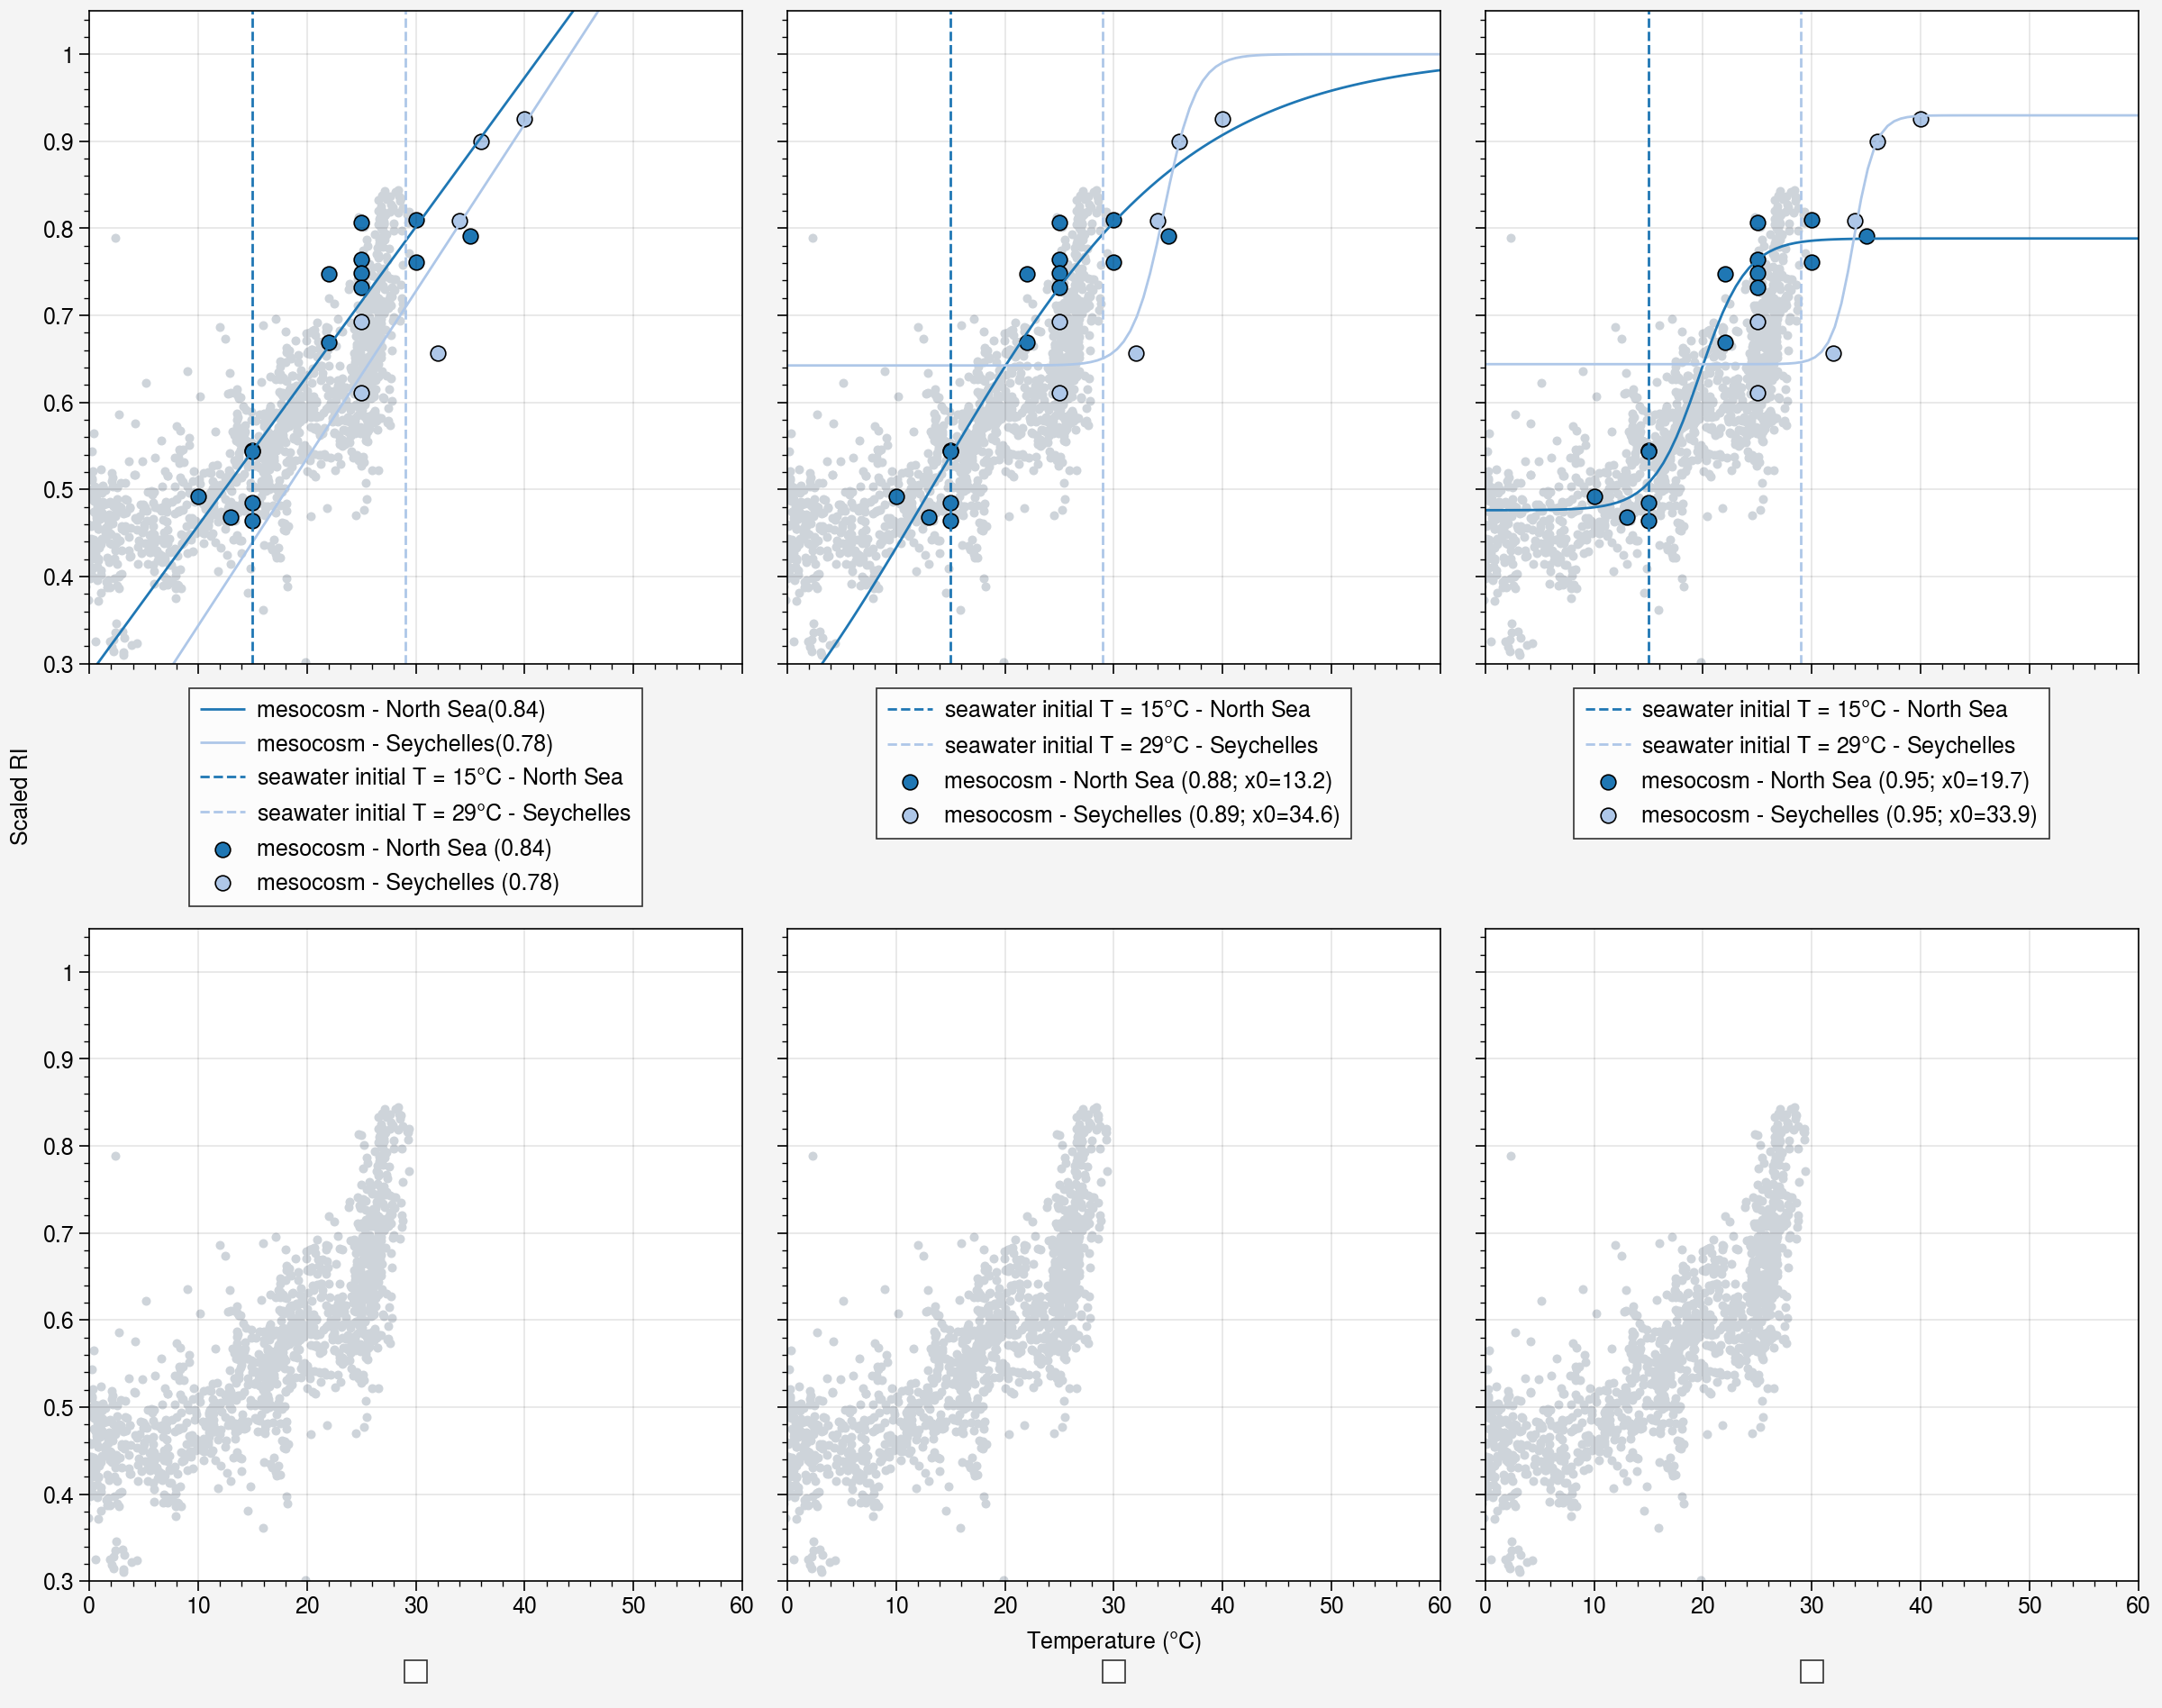

In [20]:
xx_sample = np.linspace(0, 60, 100)
fig, axs = plot.subplots(width=12,ncols=3,nrows=2)
ax = axs[0]
plot_data = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['Source']!='Verma et al. (2024) Biogeosciences']

strains_list = list((plot_data.groupby('Strains_edited')['Strains_edited'].count() >= 5).index[plot_data.groupby('Strains_edited')['Strains_edited'].count() >= 5])

new_cycler = plot.Cycle('tab20',len(strains_list))
list_new_cycler = [list(new_cycler)[i].get('color') for i in range(len(list(new_cycler)))]
strains_colordict = dict(zip(strains_list,list_new_cycler))
grouped = plot_data.groupby('Strains_edited')
for i, (name, group) in enumerate(grouped):
    if len(group) >= 5:
        if 'mesocosm' in name:

                ## linear regression
                reg_X = group['Temperature'].values.reshape(-1, 1)
                reg_y = group['scaledRI']
                ols = LinearRegression()
                ols.fit(reg_X, reg_y)
                r2 = ols.score(reg_X, reg_y)
                y_sample = ols.predict(xx_sample.reshape(-1, 1))
                axs[0,0].plot(xx_sample, y_sample, c=strains_colordict.get(name,'gray5'), ls='-', lw=1,
                                label=name+f'({r2:.2f})')
                axs[0,0].scatter(group['Temperature'], group['scaledRI'],mec='k',
                        c=strains_colordict.get(name,'gray5'),label=name+f' ({r2:.2f})', m='o')

                ## curve fit logistic fixed
                p0_fixed = [25, 0.1, 0.1]
                bounds_fixed = (0, [50, 1, 1])
                popt_fixed, pcov_fixed = scipy.optimize.curve_fit(logistic_fixed_upper, group['Temperature'], group['scaledRI'], p0=p0_fixed, bounds=bounds_fixed)
                y_sample = logistic_fixed_upper(xx_sample, *popt_fixed)
                
                ## score for logistic fixed 
                y_residual = group['scaledRI'] - logistic_fixed_upper(group['Temperature'], *popt_fixed)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                fitted_x0_fixed = popt_fixed[0]
                axs[0,1].scatter(group['Temperature'], group['scaledRI'],mec='k', 
                        c=strains_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}; x0={fitted_x0_fixed:.1f})', m='o')
                axs[0,1].plot(xx_sample, y_sample, c=strains_colordict.get(name,'gray5'), ls='-', lw=1)
                
                ## curve fit logistic 
                p0 = [25, 0.1, 0.1, 0.1]
                bounds = (0, [50, 1, 1, 1])
                popt, pcov = scipy.optimize.curve_fit(logistic, group['Temperature'], group['scaledRI'], p0=p0, 
                                                        bounds=bounds
                                                        )
                y_sample = logistic(xx_sample, *popt)

                ## score for logistic
                y_residual = group['scaledRI'] - logistic(group['Temperature'], *popt)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                fitted_x0 = popt[0]
                axs[0,2].scatter(group['Temperature'], group['scaledRI'],mec='k',
                        c=strains_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}; x0={fitted_x0:.1f})', m='o')
                axs[0,2].plot(xx_sample, y_sample, c=strains_colordict.get(name,'gray5'), ls='-', lw=1)
        else:
            
                reg_X = group['Temperature'].values.reshape(-1, 1)
                reg_y = group['scaledRI']
                ols = LinearRegression()
                ols.fit(reg_X, reg_y)
                y_sample = ols.predict(xx_sample.reshape(-1, 1))
                axs[1,0].plot(xx_sample, y_sample, c=strains_colordict.get(name,'gray5'), ls='-', lw=1)
                ## score 
                r2 = ols.score(reg_X, reg_y)

                axs[1,0].scatter(group['Temperature'], group['scaledRI'],mec='k', 
                        c=strains_colordict.get(name,'gray5'),label=name+f' ({r2:.2f})', m='o')
                

                ### logistic_fixed_upper regression with curve_fit
                p0_fixed = [25, 0.1, 0.1]
                bounds_fixed = (0, [50, 1, 1])
                popt_fixed, pcov_fixed = scipy.optimize.curve_fit(logistic_fixed_upper, group['Temperature'], group['scaledRI'], p0=p0_fixed, bounds=bounds_fixed)
                y_sample = logistic_fixed_upper(xx_sample, *popt_fixed)

                fitted_x0_fixed = popt_fixed[0]
                axs[1,1].plot(xx_sample, y_sample, c=strains_colordict.get(name,'gray5'), ls='-', lw=1)
                ## score for logistic
                y_residual = group['scaledRI'] - logistic_fixed_upper(group['Temperature'], *popt_fixed)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                axs[1,1].scatter(group['Temperature'], group['scaledRI'],mec='k', 
                        c=strains_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}; x0={fitted_x0_fixed:.1f})', m='o')
                
                ## curve fit logistic
                p0 = [25, 0.1, 0.1, 0.1]
                bounds = (0, [50, 1, 1, 1])
                popt, pcov = scipy.optimize.curve_fit(logistic, group['Temperature'], group['scaledRI'], p0=p0,
                                                        bounds=bounds
                                                        )
                y_sample = logistic(xx_sample, *popt)
                fitted_x0 = popt[0]
                axs[1,2].plot(xx_sample, y_sample, c=strains_colordict.get(name,'gray5'), ls='-', lw=1)
                ## score for logistic
                y_residual = group['scaledRI'] - logistic(group['Temperature'], *popt)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                axs[1,2].scatter(group['Temperature'], group['scaledRI'],mec='k',
                    c=strains_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}); x0={fitted_x0:.1f})', m='o')
            
reg_mesocosm = culture_meso_df[culture_meso_df['experiment_setup']=='mesocosm'].reset_index(drop=True)
X = reg_mesocosm['Temperature'].values.reshape(-1, 1)
y = reg_mesocosm['scaledRI']
ols = LinearRegression()
ols.fit(X, y)
y_sample = ols.predict(xx_sample.reshape(-1, 1))
# axs.plot(xx_sample, y_sample, color='k', lw=1.5, label='OLS (all meso)')

### initial water temperature for mesocosm
axs[0,:].axvline(15, color=strains_colordict.get('mesocosm - North Sea'), ls='--', lw=1, label ='seawater initial T = 15$\degree$C - North Sea')
axs[0,:].axvline(29, color=strains_colordict.get(name,'mesocosm - Seychelles'), ls='--', lw=1, label ='seawater initial T = 29$\degree$C - Seychelles')

for ax in axs:
    ax.set_xlabel('Temperature ($\degree$C)')
    ax.set_ylabel('Scaled RI')
    ax.set_xlim(0, 60)
    ax.set_ylim(-0.5, 1.05)

    h, l = ax.get_legend_handles_labels()
    ax.legend(h, loc='b', fontsize=8,ncols=1,)

# h0, l0 = axs[0].get_legend_handles_labels()
# axs[0,-1].legend(h0, loc='b', fontsize=8,ncols=1,)

# h1, l1 = axs[1].get_legend_handles_labels()
# axs[1].legend(h1, loc='b', fontsize=8,ncols=1,)

# h2, l2 = axs[2].get_legend_handles_labels()
# axs[2].legend(h2, loc='b', fontsize=8,ncols=1,)

# h3, l3 = axs[3].get_legend_handles_labels()
# axs[3].legend(h3, loc='b', fontsize=8,ncols=1,)

axs.format(ylim=(0.3,1.05),)

#### plot coretop T vs scaledRI
plot_x = coretop_da['t_sf2tc_avg']
plot_y = coretop_da['scaledRI_median']
axs.scatter(plot_x, plot_y, c='gray4', m='.', zorder=0)

(<matplotlib.collections.PathCollection at 0x7fd019a77a00>,
 <matplotlib.collections.PathCollection at 0x7fd019c2b790>)

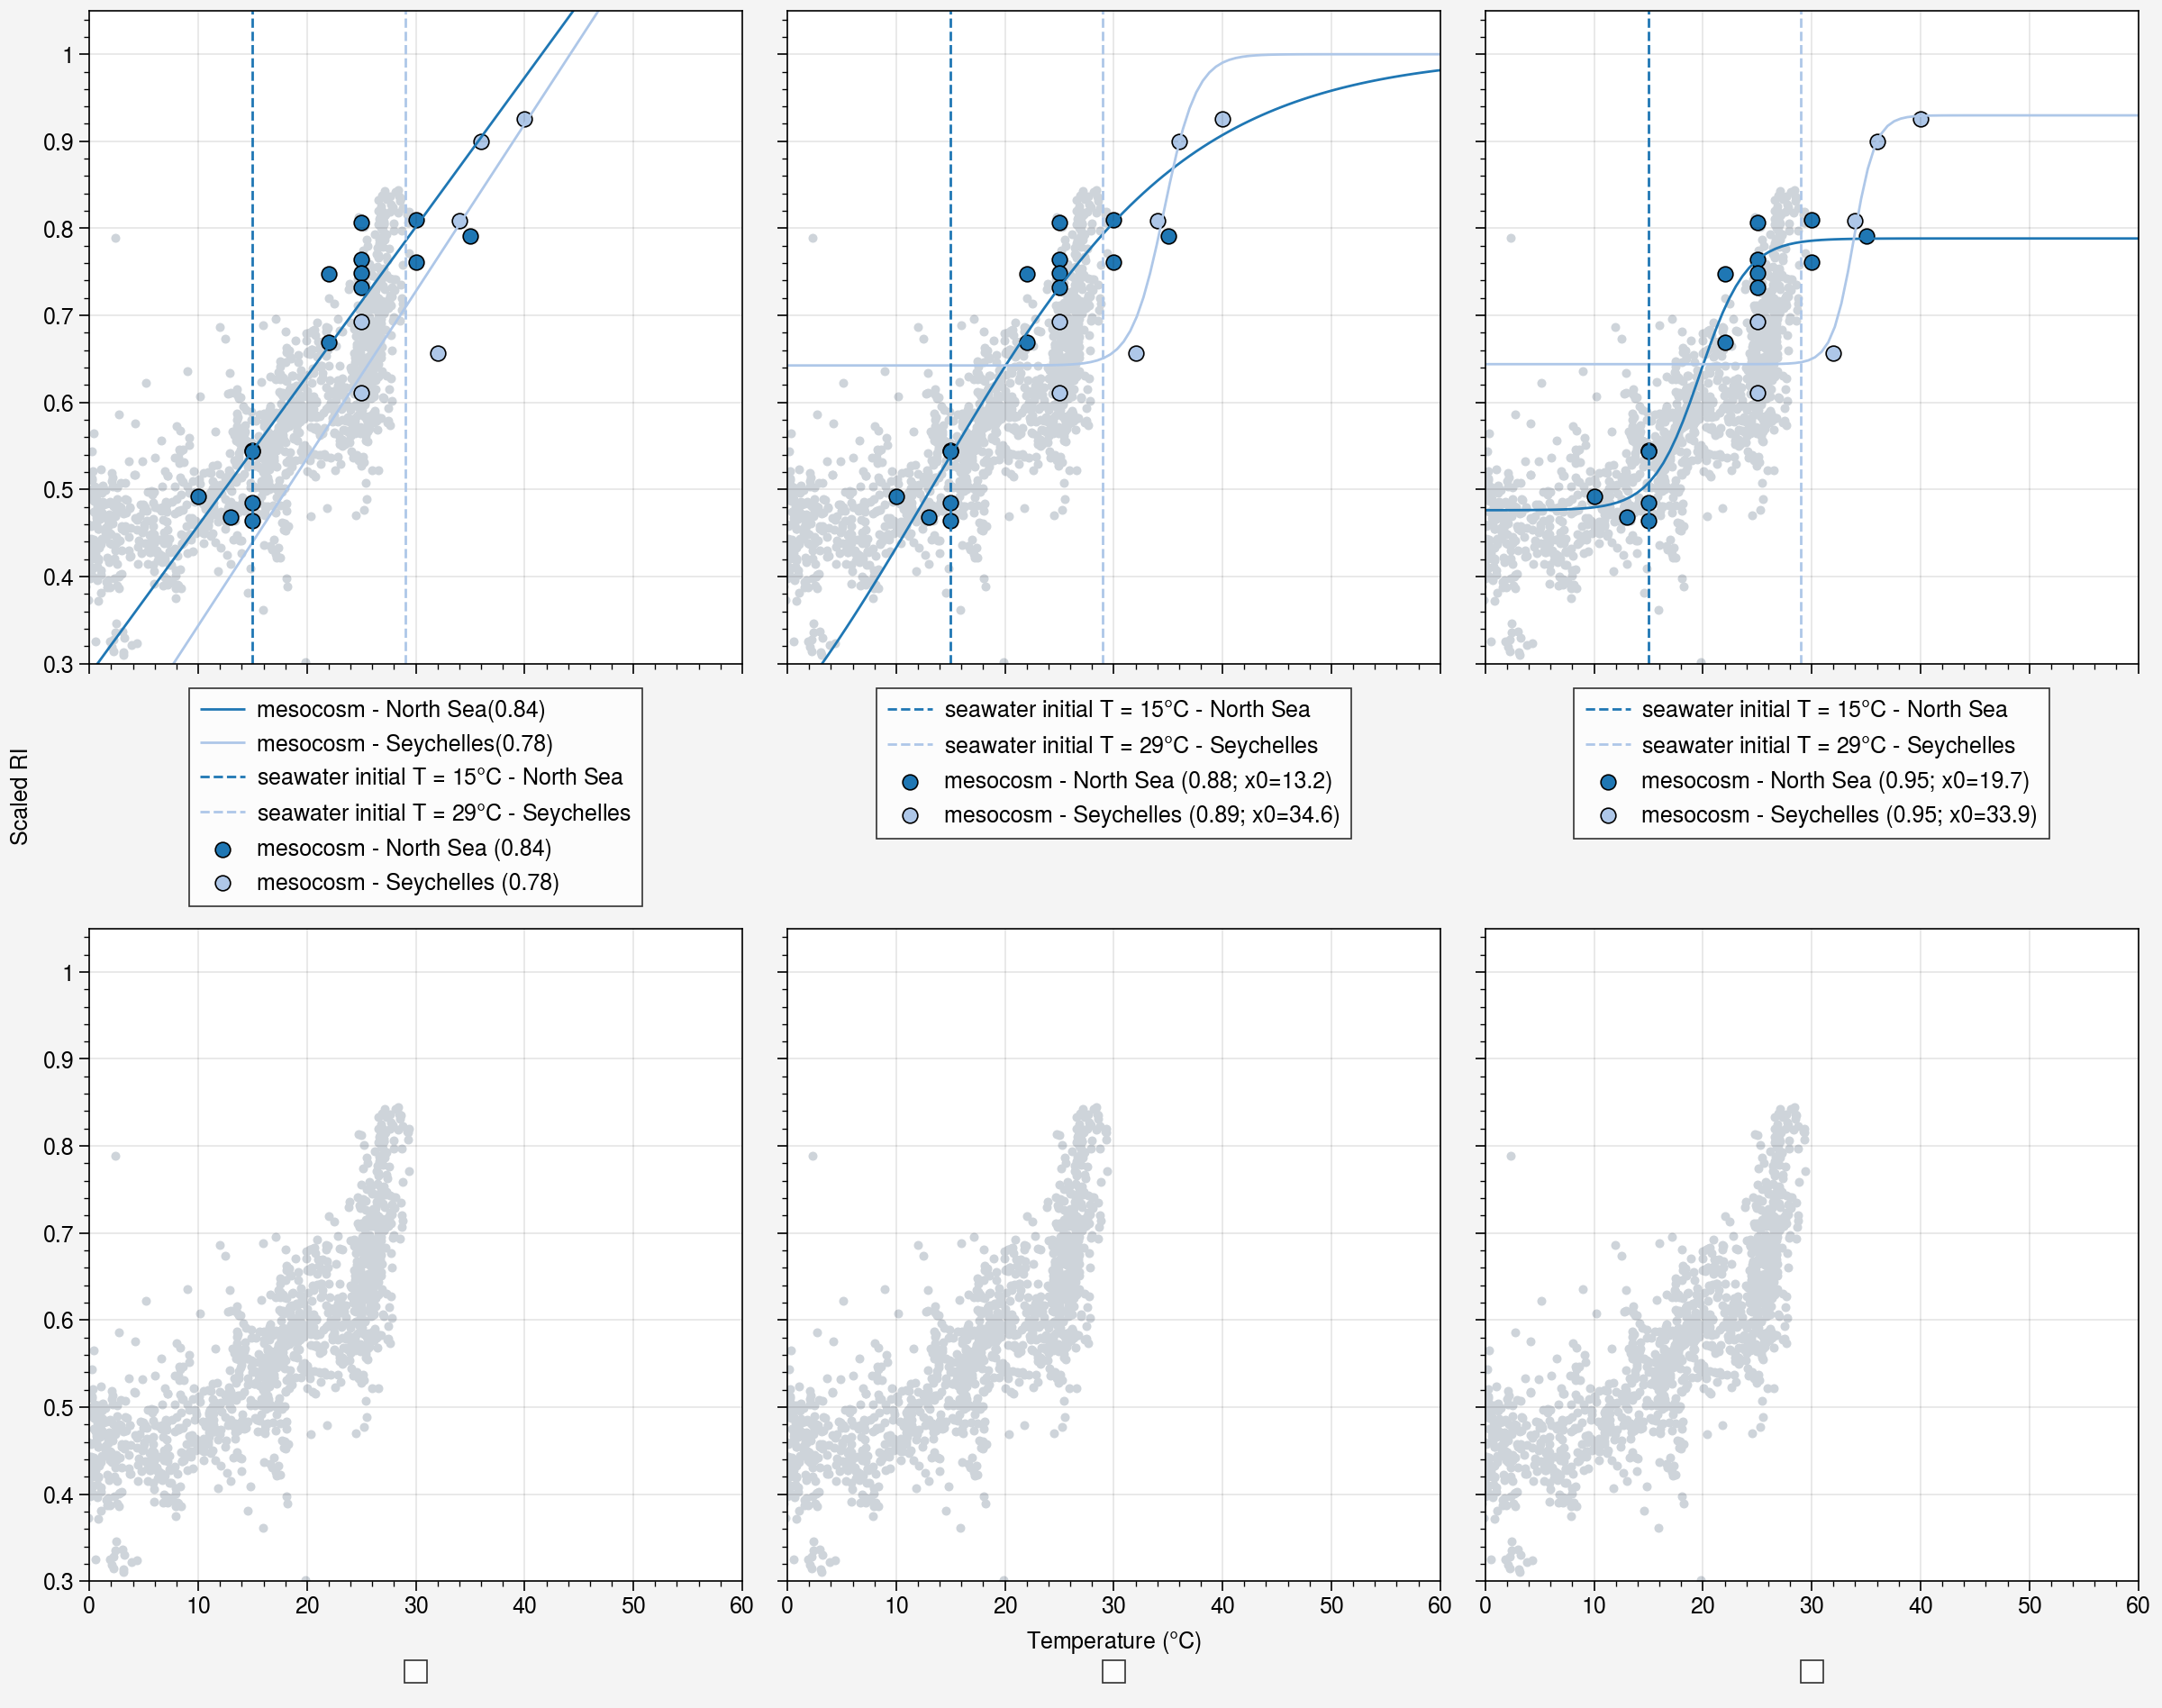

In [21]:
xx_sample = np.linspace(0, 60, 100)
fig, axs = plot.subplots(width=12,ncols=3,nrows=2)
ax = axs[0]
plot_data = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['Source']!='Verma et al. (2024) Biogeosciences']

genus_list = list((plot_data.groupby('GTDB_genus_edited')['GTDB_genus_edited'].count() >= 0).index[plot_data.groupby('GTDB_genus_edited')['GTDB_genus_edited'].count() >= 5])

new_cycler = plot.Cycle('tab20',len(genus_list))
list_new_cycler = [list(new_cycler)[i].get('color') for i in range(len(list(new_cycler)))]
genus_colordict = dict(zip(genus_list,list_new_cycler))
grouped = plot_data.groupby('GTDB_genus_edited')
for i, (name, group) in enumerate(grouped):
    if len(group) >= 5:
        if 'mesocosm' in name:

                ## linear regression
                reg_X = group['Temperature'].values.reshape(-1, 1)
                reg_y = group['scaledRI']
                ols = LinearRegression()
                ols.fit(reg_X, reg_y)
                r2 = ols.score(reg_X, reg_y)
                y_sample = ols.predict(xx_sample.reshape(-1, 1))
                axs[0,0].plot(xx_sample, y_sample, c=genus_colordict.get(name,'gray5'), ls='-', lw=1,
                                label=name+f'({r2:.2f})')
                axs[0,0].scatter(group['Temperature'], group['scaledRI'],mec='k',
                        c=genus_colordict.get(name,'gray5'),label=name+f' ({r2:.2f})', m='o')

                ## curve fit logistic fixed
                p0_fixed = [25, 0.1, 0.1]
                bounds_fixed = (0, [50, 1, 1])
                popt_fixed, pcov_fixed = scipy.optimize.curve_fit(logistic_fixed_upper, group['Temperature'], group['scaledRI'], p0=p0_fixed, bounds=bounds_fixed)
                y_sample = logistic_fixed_upper(xx_sample, *popt_fixed)
                
                ## score for logistic fixed 
                y_residual = group['scaledRI'] - logistic_fixed_upper(group['Temperature'], *popt_fixed)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                fitted_x0_fixed = popt_fixed[0]
                axs[0,1].scatter(group['Temperature'], group['scaledRI'],mec='k', 
                        c=genus_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}; x0={fitted_x0_fixed:.1f})', m='o')
                axs[0,1].plot(xx_sample, y_sample, c=genus_colordict.get(name,'gray5'), ls='-', lw=1)
                
                ## curve fit logistic 
                p0 = [25, 0.1, 0.1, 0.1]
                bounds = (0, [50, 1, 1, 1])
                popt, pcov = scipy.optimize.curve_fit(logistic, group['Temperature'], group['scaledRI'], p0=p0, 
                                                        bounds=bounds
                                                        )
                y_sample = logistic(xx_sample, *popt)

                ## score for logistic
                y_residual = group['scaledRI'] - logistic(group['Temperature'], *popt)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                fitted_x0 = popt[0]
                axs[0,2].scatter(group['Temperature'], group['scaledRI'],mec='k',
                        c=genus_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}; x0={fitted_x0:.1f})', m='o')
                axs[0,2].plot(xx_sample, y_sample, c=genus_colordict.get(name,'gray5'), ls='-', lw=1)
        else:
            
                reg_X = group['Temperature'].values.reshape(-1, 1)
                reg_y = group['scaledRI']
                ols = LinearRegression()
                ols.fit(reg_X, reg_y)
                y_sample = ols.predict(xx_sample.reshape(-1, 1))
                axs[1,0].plot(xx_sample, y_sample, c=genus_colordict.get(name,'gray5'), ls='-', lw=1)
                ## score 
                r2 = ols.score(reg_X, reg_y)

                axs[1,0].scatter(group['Temperature'], group['scaledRI'],mec='k', 
                        c=genus_colordict.get(name,'gray5'),label=name+f' ({r2:.2f})', m='o')
                

                ### logistic_fixed_upper regression with curve_fit
                p0_fixed = [25, 0.1, 0.1]
                bounds_fixed = (0, [50, 1, 1])
                popt_fixed, pcov_fixed = scipy.optimize.curve_fit(logistic_fixed_upper, group['Temperature'], group['scaledRI'], p0=p0_fixed, bounds=bounds_fixed)
                y_sample = logistic_fixed_upper(xx_sample, *popt_fixed)

                fitted_x0_fixed = popt_fixed[0]
                axs[1,1].plot(xx_sample, y_sample, c=genus_colordict.get(name,'gray5'), ls='-', lw=1)
                ## score for logistic
                y_residual = group['scaledRI'] - logistic_fixed_upper(group['Temperature'], *popt_fixed)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                axs[1,1].scatter(group['Temperature'], group['scaledRI'],mec='k', 
                        c=genus_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}; x0={fitted_x0_fixed:.1f})', m='o')
                
                ## curve fit logistic
                p0 = [25, 0.1, 0.1, 0.1]
                bounds = (0, [50, 1, 1, 1])
                popt, pcov = scipy.optimize.curve_fit(logistic, group['Temperature'], group['scaledRI'], p0=p0,
                                                        bounds=bounds
                                                        )
                y_sample = logistic(xx_sample, *popt)
                fitted_x0 = popt[0]
                axs[1,2].plot(xx_sample, y_sample, c=genus_colordict.get(name,'gray5'), ls='-', lw=1)
                ## score for logistic
                y_residual = group['scaledRI'] - logistic(group['Temperature'], *popt)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                axs[1,2].scatter(group['Temperature'], group['scaledRI'],mec='k',
                    c=genus_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}); x0={fitted_x0:.1f})', m='o')
            
reg_mesocosm = culture_meso_df[culture_meso_df['experiment_setup']=='mesocosm'].reset_index(drop=True)
X = reg_mesocosm['Temperature'].values.reshape(-1, 1)
y = reg_mesocosm['scaledRI']
ols = LinearRegression()
ols.fit(X, y)
y_sample = ols.predict(xx_sample.reshape(-1, 1))
# axs.plot(xx_sample, y_sample, color='k', lw=1.5, label='OLS (all meso)')

### initial water temperature for mesocosm
axs[0,:].axvline(15, color=genus_colordict.get('mesocosm - North Sea'), ls='--', lw=1, label ='seawater initial T = 15$\degree$C - North Sea')
axs[0,:].axvline(29, color=genus_colordict.get('mesocosm - Seychelles'), ls='--', lw=1, label ='seawater initial T = 29$\degree$C - Seychelles')

for ax in axs:
    ax.set_xlabel('Temperature ($\degree$C)')
    ax.set_ylabel('Scaled RI')
    ax.set_xlim(0, 60)
    ax.set_ylim(-0.5, 1.05)

    h, l = ax.get_legend_handles_labels()
    ax.legend(h, loc='b', fontsize=8,ncols=1,)

# h0, l0 = axs[0].get_legend_handles_labels()
# axs[0,-1].legend(h0, loc='b', fontsize=8,ncols=1,)

# h1, l1 = axs[1].get_legend_handles_labels()
# axs[1].legend(h1, loc='b', fontsize=8,ncols=1,)

# h2, l2 = axs[2].get_legend_handles_labels()
# axs[2].legend(h2, loc='b', fontsize=8,ncols=1,)

# h3, l3 = axs[3].get_legend_handles_labels()
# axs[3].legend(h3, loc='b', fontsize=8,ncols=1,)

axs.format(ylim=(0.3,1.05),)

#### plot coretop T vs scaledRI
plot_x = coretop_da['t_sf2tc_avg']
plot_y = coretop_da['scaledRI_median']
axs.scatter(plot_x, plot_y, c='gray4', m='.', zorder=0)

In [22]:
plot_data = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['Source']!='Verma et al. (2024) Biogeosciences']

# Get strains with at least 5 occurrences
strain_counts = plot_data['Strains_edited'].value_counts()
strains_list = strain_counts[strain_counts >= 5].index.tolist()


plot_data_filtered = plot_data[plot_data['Strains_edited'].isin(strains_list)].reset_index(drop=True)
plot_data_filtered.groupby(['Strains_edited','Source','NCBI_family']).size().sort_values(ascending=False).reset_index(name='counts')

,Strains_edited,Source,NCBI_family,counts
0,mesocosm - North Sea,Wuchter2004,mesocosm,15
1,mesocosm - Seychelles,Schouten2007,mesocosm,6


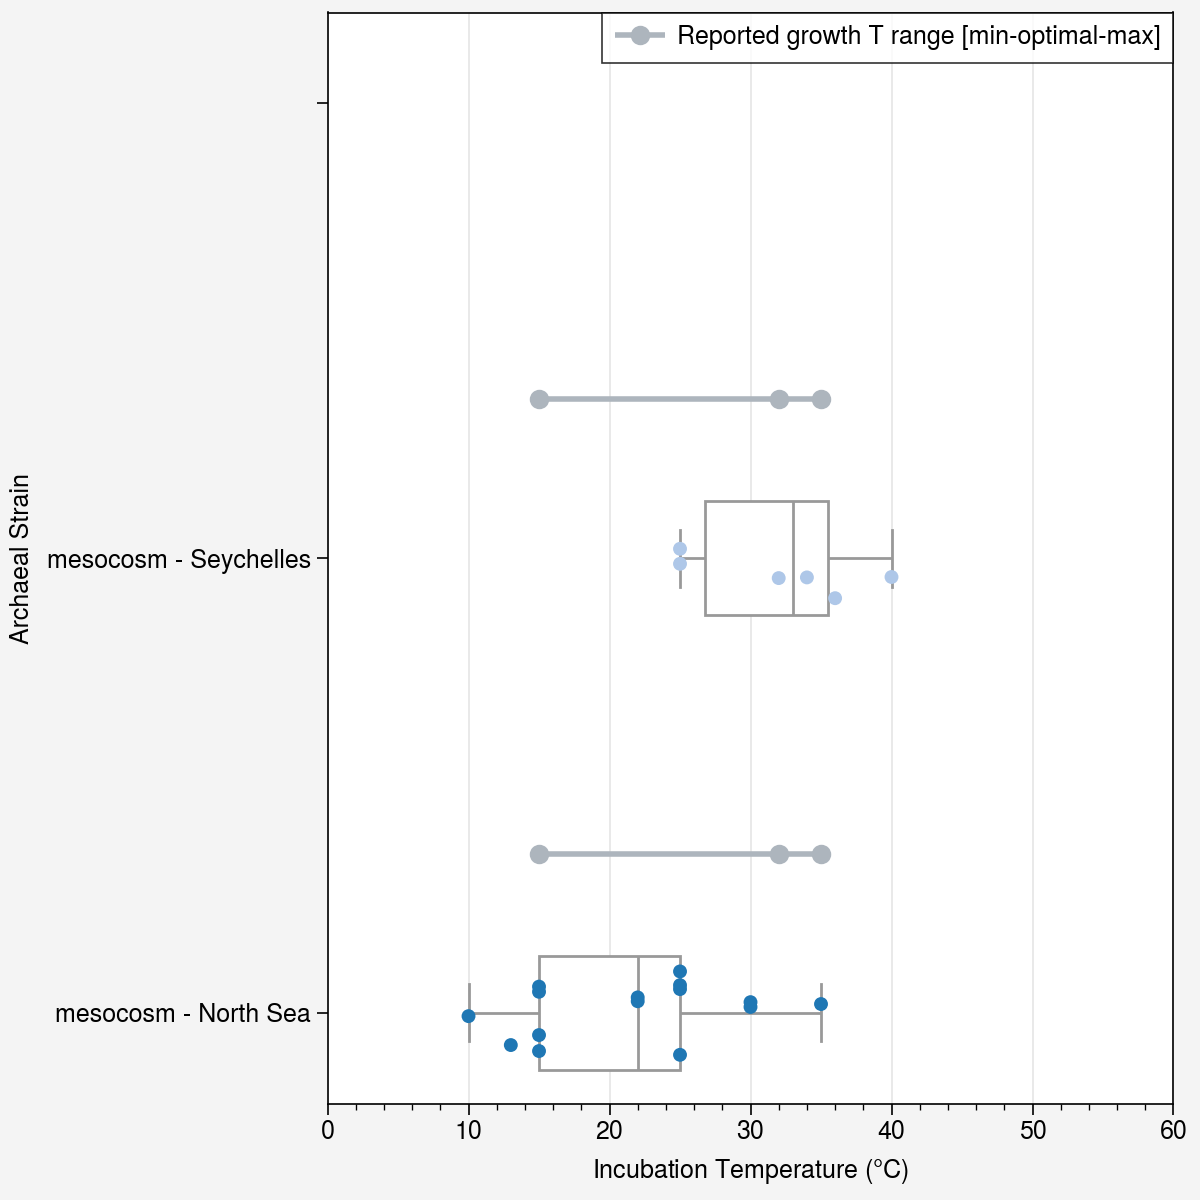

In [23]:
plot_data = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['Source']!='Verma et al. (2024) Biogeosciences']

# Get strains with at least 5 occurrences
strain_counts = plot_data['Strains_edited'].value_counts()
strains_list = strain_counts[strain_counts >= 5].index.tolist()


plot_data_filtered = plot_data[plot_data['Strains_edited'].isin(strains_list)].reset_index(drop=True)

# Define the known optimal temperature ranges for each strain
optimal_temp_ranges = {
    ### information from BacDive bacdive.dsmz.de
    'D3C': (15, 32, 37), ## Elling et al (unpublished) | Bayer et al. 2019 (https://www.microbiologyresearch.org/content/journal/ijsem/10.1099/ijsem.0.003360)
    'EN76': (28, 42, 47), ## N. viennensis | Elling et al (unpublished) | Stieglmeier et al. 2014 (https://www.microbiologyresearch.org/content/journal/ijsem/10.1099/ijs.0.063172-0), Tourna et al. 2011 (PNAS; https://www.pnas.org/doi/10.1073/pnas.1013488108#fig01)
    'Ga9.2': (30, 46, 55), ## N. Gargensis | Pitcher et al. (2010), Elling et al. (2017) | Chow et al. (2018) (https://www.nature.com/articles/s41598-018-32059-0#:~:text=The%20carboxylesterase%20was%20mostly%20active,(%E2%88%BC46%20%C2%B0C).)
    'HCA1': (10, 25, 30), ## Qin et al. (2015) PNAS | Bayer et al. 2019 (https://www.microbiologyresearch.org/content/journal/ijsem/10.1099/ijsem.0.003360)
    'HCE1': (4, 25, 30), ## Qin et al. (2015) PNAS | Bayer et al. 2019 (https://www.microbiologyresearch.org/content/journal/ijsem/10.1099/ijsem.0.003360)
    'MY1T': (20, 25,30), ## Jung et al. (2011) GDGT and growth conditions
    # 'NAOA2': (25, 35), ## 
    'SCM1': (15, 32, 35), ## Elling et al. (2015) GCA & Qin et al. (2015) PNAS  | Bayer et al. 2019 (https://www.microbiologyresearch.org/content/journal/ijsem/10.1099/ijsem.0.003360)
    'mesocosm - North Sea': (15, 32, 35), ## Assuming close to SCM1 based on phylogenetic tree of Wuchter et al. (2004) PNAS
    'mesocosm - Seychelles': (15, 32, 35),  ## Assuming close to SCM1 based on phylogenetic tree of Schouten et al. (2007) Organic Geochemistry
}
# Get unique strains in the correct plotting order
strain_order = plot_data_filtered['Strains_edited'].unique()

fig, axs = plot.subplots(figsize=(6,6))
ax = axs[0]

sns.stripplot(data=plot_data_filtered, x='Temperature', y='Strains_edited', 
              hue='Strains_edited', palette=strains_colordict, legend=False,
              ax=ax)
sns.boxplot(data=plot_data_filtered, x='Temperature', y='Strains_edited', 
            color='white', ax=ax, linewidth=1, fliersize=0, legend=False,
            width=0.25)

# Add horizontal bars for optimal temperature ranges
for strain, (temp_min, temp_opt, temp_max) in optimal_temp_ranges.items():
    if strain in strain_order:  # Ensure the strain exists in the filtered data
        y_pos = np.where(strain_order == strain)[0][0]  # Find index in strain_order
        ax.plot([temp_min, temp_opt, temp_max], [y_pos+0.35, y_pos+0.35, y_pos+0.35], m='o', ls='-', c='gray5', lw=2, label='Optimal T range')


### add 'source' from the dataframe to each line


ax.format(
    yticks=np.arange(0, len(plot_data_filtered['Strains_edited'].unique()) + 0.5, 1),
    yticklabels=list(plot_data_filtered['Strains_edited'].unique()),
    ytickminor=False,
    xlabel='Incubation Temperature ($\degree$C)',
    ylabel='Archaeal Strain',
    xlim=(0, 60),
    ylim=(-0.2, len(plot_data_filtered['Strains_edited'].unique()) + 0.2),
)

h, l = ax.get_legend_handles_labels()
ax.legend(h[0], 'Reported growth T range [min-optimal-max]', loc='ur', fontsize=8,ncols=1, title_fontsize=8)



In [24]:
SCM1_df = culture_meso_df[culture_meso_df['Strains']=='SCM1'].reset_index(drop=True)
SCM1_df

,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,Strains_edited,GTDB_genus_edited
